3784795.6425104155
[ 0.53475646  3.50923815 -3.95360218 -2.38160976]


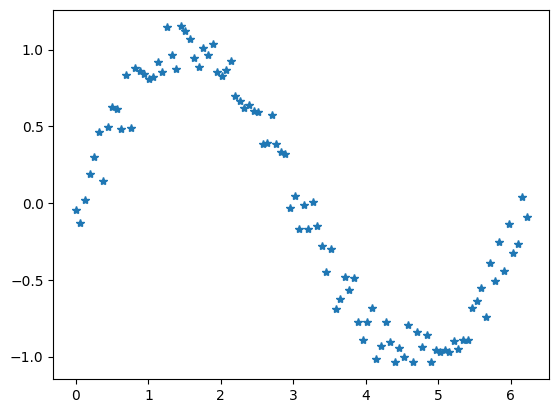

In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

N = 50
x = np.arange(N) * 2 * np.pi/ N #説明変数
fx = np.sin(x) + np.random.normal(0, 0.1, N) #データ生成

plt.plot(x, fx, "*")

dim = 3 # 次元数
w = (np.random.rand(dim+1) -0.5) * 10 # パラメータ[w1, w2,..., w(dim+1)]
error = 0 # 誤差関数
lamb = 1

x_poly = np.zeros((N, dim+1)) # 基底関数[1, x[i], x[i]**2, ..., x[i]**dim](N*dim+1)
x_poly[:,0] = 1
for i in range(dim):
  x_poly[:,i+1] = x**(i+1)


fx_pred = x_poly @ w # fxの予測値
error = (1/2)*np.sum((fx_pred - fx[range(N)])**2) + (lamb/2) * np.linalg.norm(w)**2
# E(w) = (1/2)(二乗誤差)+(lamb/2)*|w|^2 (リッジ解析)

print(error)
print(w)


In [ ]:

t = 1e-6 # ステップサイズ(固定)
d = np.zeros(dim+1) # 降下方向
time = 1000000 #繰り返し数
error_rec = np.zeros(time)
d_rec = np.zeros(time)

# 最急降下法によるerrorの最小化
for n in range(time):

  # # 勾配ベクトルを計算
  d = x_poly.T @ (x_poly @ w - fx[range(N)]) + lamb * w

  # パラメータを更新
  w = w - t * d

  error = (1/2)*np.sum((x_poly @ w - fx[range(N)])**2) + (lamb/2) * np.linalg.norm(w)**2

  error_rec[n] = error
  d_rec[n] = np.linalg.norm(d)


fx_pred = np.dot(x_poly, w) # 最終的な予測値でプロット

plt.plot(x, fx, "*", label="観測データ")
plt.plot(x, fx_pred, label="予測曲線")
plt.show()

plt.plot(error_rec)
plt.ylabel("誤差")
plt.show()

print(error)
print(w)



KeyboardInterrupt



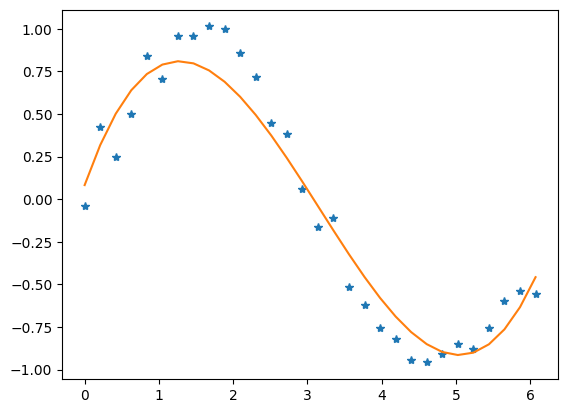

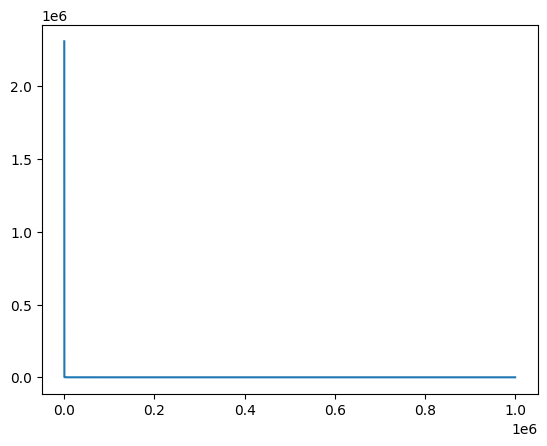

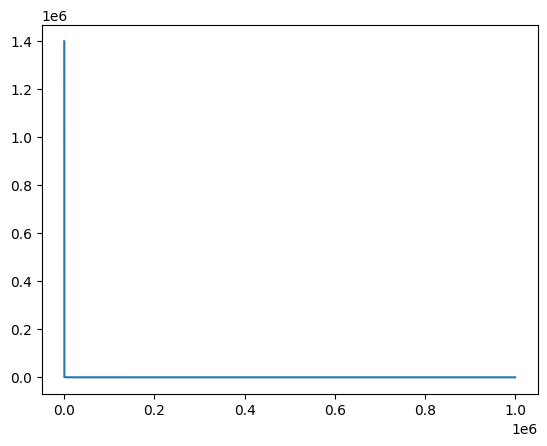

In [ ]:
plt.figure()
plt.plot(x, fx, "*")
plt.plot(x, fx_pred)

plt.figure()
plt.plot(error_rec)

plt.figure()
plt.plot(d_rec)

In [25]:
%%bash


/content
